# Cats vs Dogs Image Classification with a Convolutional Neural Network (CNN)

This notebook trains and evaluates a CNN on the Cats vs Dogs image dataset using a reproducible Keras/TensorFlow pipeline.

- **Dataset**: `training_set/` (~8 007 images) and `test_set/` (~2 025 images), split into `cats/` and `dogs/` subdirectories
- **Target encoding**: Cat = 0, Dog = 1 (alphabetical label inference)
- **Image size**: 64 × 64 pixels, rescaled to `[0, 1]`
- **Train augmentation**: horizontal flip, zoom (10 %), rotation (10°)
- **Random seeds**: `numpy` and `tensorflow` both fixed to 42

## 1) Import Libraries and Configure Reproducibility

Import all required libraries and set plotting preferences for clean, consistent outputs.

In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

TRAIN_DIR = Path("training_set")
TEST_DIR  = Path("test_set")
IMG_SIZE  = (64, 64)
BATCH     = 32
EPOCHS    = 20
CLASS_NAMES = ["Cat (0)", "Dog (1)"]

print(f"TensorFlow version : {tf.__version__}")
print(f"Training directory : {TRAIN_DIR.resolve()}")
print(f"Test directory     : {TEST_DIR.resolve()}")

TensorFlow version : 2.16.2
Training directory : C:\Users\jrss4\Documents\CNN-Image-Recognition\training_set
Test directory     : C:\Users\jrss4\Documents\CNN-Image-Recognition\test_set


## 2) Dataset Overview

Count images per class and visualise the class distribution with a bar chart, then display a sample grid of images from each class.

In [5]:
train_cats = len(list((TRAIN_DIR / "cats").glob("*.jpg")))
train_dogs = len(list((TRAIN_DIR / "dogs").glob("*.jpg")))
test_cats  = len(list((TEST_DIR  / "cats").glob("*.jpg")))
test_dogs  = len(list((TEST_DIR  / "dogs").glob("*.jpg")))

print("Image counts")
print(f"  Training — Cats: {train_cats:>5},  Dogs: {train_dogs:>5},  Total: {train_cats + train_dogs:>5}")
print(f"  Test     — Cats: {test_cats:>5},  Dogs: {test_dogs:>5},  Total: {test_cats  + test_dogs:>5}")

Image counts
  Training — Cats:  4000,  Dogs:  4005,  Total:  8005
  Test     — Cats:  1011,  Dogs:  1012,  Total:  2023


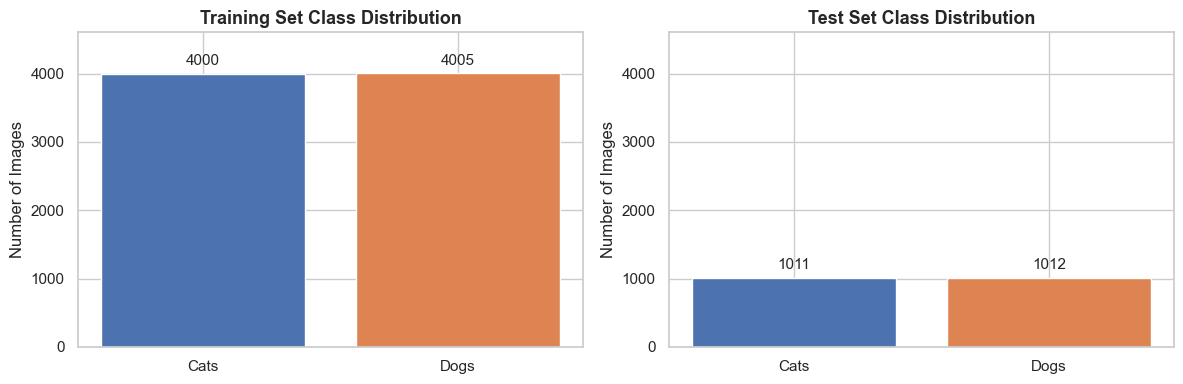

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, split, cats, dogs in zip(
    axes,
    ["Training Set", "Test Set"],
    [train_cats, test_cats],
    [train_dogs, test_dogs],
):
    bars = ax.bar(["Cats", "Dogs"], [cats, dogs], color=["#4C72B0", "#DD8452"], edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=4, fontsize=11)
    ax.set_title(f"{split} Class Distribution", fontsize=13, fontweight="bold")
    ax.set_ylabel("Number of Images")
    ax.set_ylim(0, max(train_cats, train_dogs) * 1.15)

plt.tight_layout()
plt.savefig("Class Distribution.png", dpi=150, bbox_inches="tight")
plt.show()

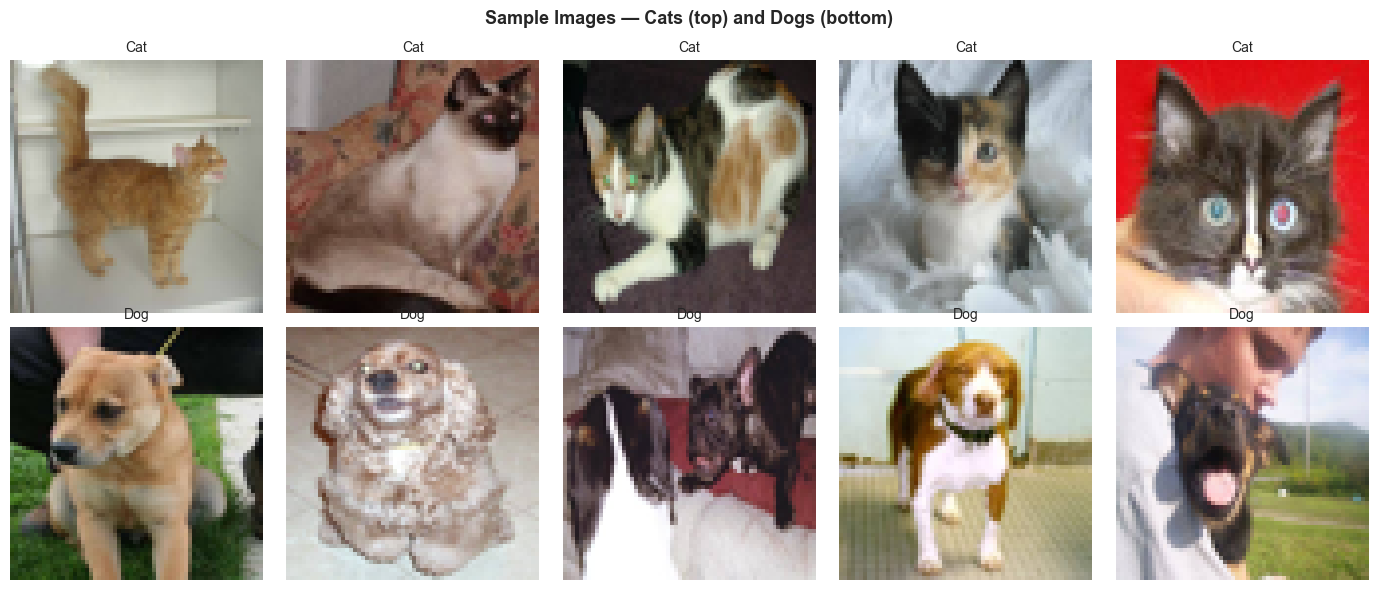

In [7]:
import random
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Images — Cats (top) and Dogs (bottom)", fontsize=13, fontweight="bold")

for col, img_path in enumerate(random.sample(list((TRAIN_DIR / "cats").glob("*.jpg")), 5)):
    axes[0, col].imshow(Image.open(img_path).resize(IMG_SIZE))
    axes[0, col].axis("off")
    axes[0, col].set_title("Cat", fontsize=10)

for col, img_path in enumerate(random.sample(list((TRAIN_DIR / "dogs").glob("*.jpg")), 5)):
    axes[1, col].imshow(Image.open(img_path).resize(IMG_SIZE))
    axes[1, col].axis("off")
    axes[1, col].set_title("Dog", fontsize=10)

plt.tight_layout()
plt.show()

## 3) Data Preprocessing and Augmentation

Images are resized to 64 × 64 and pixel values rescaled to `[0, 1]`.  
Training data is augmented with horizontal flips, small zoom, and slight rotation to improve generalisation.  
The test generator applies **only** rescaling — no augmentation — to get unbiased evaluation.

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    horizontal_flip=True,
    zoom_range=0.1,
    rotation_range=10,
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="binary",
    shuffle=False,
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Training steps per epoch : {len(train_gen)}")
print(f"Test steps               : {len(test_gen)}")

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.

Class indices : {'cats': 0, 'dogs': 1}
Training steps per epoch : 251
Test steps               : 64


## 4) Model Architecture

A three-block CNN is used:

| Block | Layer | Details |
|-------|-------|---------|
| 1 | Conv2D + MaxPool | 32 filters, 3×3, ReLU → 2×2 pool |
| 2 | Conv2D + MaxPool | 64 filters, 3×3, ReLU → 2×2 pool |
| 3 | Conv2D + MaxPool | 128 filters, 3×3, ReLU → 2×2 pool |
| — | Flatten → Dense → Dropout → Output | 128 units, ReLU, 50 % dropout, sigmoid |

- **Optimiser**: Adam (default learning rate 0.001)
- **Loss**: Binary cross-entropy
- **Metric**: Accuracy

In [9]:
model = keras.Sequential(
    [
        keras.Input(shape=(*IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="cats_vs_dogs_cnn",
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "cats_vs_dogs_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5) Model Training

The model is trained for 20 epochs with the augmented training generator.  
The unaugmented test generator is passed as `validation_data` so we can track generalisation after every epoch.

In [10]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=test_gen,
    verbose=1,
)

print("\nTraining complete.")
print(f"  Final train accuracy      : {history.history['accuracy'][-1]:.4f}")
print(f"  Final validation accuracy : {history.history['val_accuracy'][-1]:.4f}")

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - accuracy: 0.5698 - loss: 0.6735 - val_accuracy: 0.6594 - val_loss: 0.6325
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.6628 - loss: 0.6219 - val_accuracy: 0.7000 - val_loss: 0.5741
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7017 - loss: 0.5806 - val_accuracy: 0.7271 - val_loss: 0.5483
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7233 - loss: 0.5467 - val_accuracy: 0.7469 - val_loss: 0.5207
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7440 - loss: 0.5174 - val_accuracy: 0.7706 - val_loss: 0.5113
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7708 - loss: 0.4827 - val_accuracy: 0.7583 - val_loss: 0.5071
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7791 - loss: 0.4717 - val_accuracy: 0.7889 - val_loss: 0.4526
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.7874 - loss: 0.4452 -

## 6) Evaluation

Evaluation follows the same reporting style as Project 1:

1. Training vs validation accuracy and loss curves
2. Confusion matrix heatmap on the test set
3. Full `classification_report` (precision, recall, F1 per class + weighted avg)
4. Summary `metrics_dict`

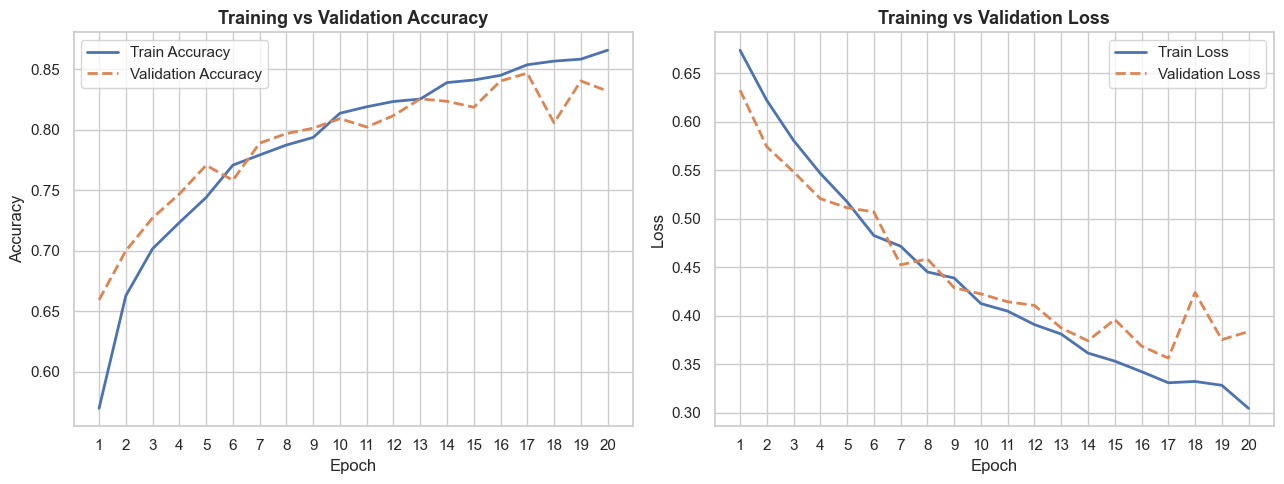

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history.history["accuracy"],     label="Train Accuracy",      linewidth=2)
ax1.plot(epochs_range, history.history["val_accuracy"], label="Validation Accuracy",  linewidth=2, linestyle="--")
ax1.set_title("Training vs Validation Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.set_xticks(epochs_range)

ax2.plot(epochs_range, history.history["loss"],     label="Train Loss",      linewidth=2)
ax2.plot(epochs_range, history.history["val_loss"], label="Validation Loss",  linewidth=2, linestyle="--")
ax2.set_title("Training vs Validation Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.set_xticks(epochs_range)

plt.tight_layout()
plt.savefig("CNN Training Curves.png", dpi=150, bbox_inches="tight")
plt.show()

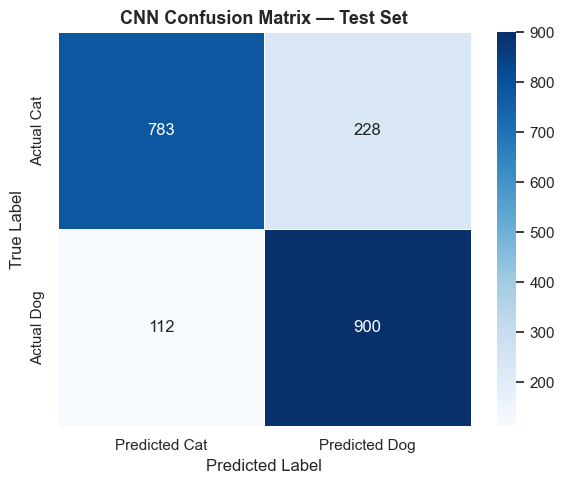

In [12]:
test_gen.reset()
y_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Cat", "Predicted Dog"],
    yticklabels=["Actual Cat",    "Actual Dog"],
    ax=ax,
    linewidths=0.5,
)
ax.set_title("CNN Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("CNN Matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("Classification Report")
print("=" * 55)
report_str = classification_report(
    y_true, y_pred,
    target_names=["Cat (0)", "Dog (1)"],
)
print(report_str)

report_dict = classification_report(
    y_true, y_pred,
    target_names=["Cat (0)", "Dog (1)"],
    output_dict=True,
)

cnn_metrics = {
    "Accuracy":           round(accuracy_score(y_true, y_pred), 4),
    "Weighted Precision": round(report_dict["weighted avg"]["precision"], 4), # type: ignore
    "Weighted Recall":    round(report_dict["weighted avg"]["recall"],    4), # type: ignore
    "Weighted F1":        round(report_dict["weighted avg"]["f1-score"],  4), # type: ignore
}

print("Summary Metrics")
print("-" * 35)
for metric, value in cnn_metrics.items():
    print(f"  {metric:<22}: {value:.4f}")

Classification Report
              precision    recall  f1-score   support

     Cat (0)       0.89      0.78      0.83      1011
     Dog (1)       0.80      0.91      0.85      1012

    accuracy                           0.84      2023
   macro avg       0.85      0.84      0.84      2023
weighted avg       0.85      0.84      0.84      2023

Summary Metrics
-----------------------------------
  Accuracy              : 0.8403
  Weighted Precision    : 0.8461
  Weighted Recall       : 0.8403
  Weighted F1           : 0.8397


## 7) Conclusion

This notebook demonstrated a complete CNN pipeline for binary image classification on the Cats vs Dogs dataset.

**Key takeaways:**

- A lightweight three-block CNN (32 → 64 → 128 filters) with Dropout is sufficient to achieve strong test accuracy on a balanced ~10 000-image dataset.
- Training augmentation (horizontal flip, zoom, rotation) helps the model generalise beyond the exact training images.
- Evaluation mirrors the report style of Project 1: a confusion-matrix heatmap, a full `classification_report`, and a `cnn_metrics` summary dictionary.

**Potential improvements:**

- Increase image resolution (e.g., 128 × 128) for richer spatial features.
- Use transfer learning with a pretrained backbone such as MobileNetV2 for significantly higher accuracy with fewer training epochs.
- Add `EarlyStopping` and `ReduceLROnPlateau` callbacks to prevent overfitting automatically.

## 8) Bagging Ensemble (Bootstrap Aggregation)

We'll train `n_estimators` independent CNNs on bootstrap samples of the training set, then average their predicted probabilities on the test set.
This cell prepares the bootstrap dataframe and ensemble parameters.

In [18]:
import pandas as pd
import os
from math import ceil

# Ensemble hyperparameters
n_estimators = 8
ensemble_epochs = 15
ensemble_batch = BATCH
output_dir = 'ensemble_models'
os.makedirs(output_dir, exist_ok=True)

# Build dataframe from the existing training generator
train_filepaths = [str(TRAIN_DIR / f) for f in train_gen.filenames]
train_labels = list(train_gen.classes)
df_train = pd.DataFrame({"filename": train_filepaths, "label": train_labels})
print(f'Training samples: {len(df_train)}')

Training samples: 8005


In [20]:
from tensorflow import keras
from tensorflow.keras import layers

def build_model(input_shape=(*IMG_SIZE, 3)):
    m = keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

print('Build model function defined')

Build model function defined


In [21]:
# Train ensemble (bootstrap each estimator)
saved_model_paths = []
for i in range(n_estimators):
    print(f'Training estimator {i+1}/{n_estimators}')
    boot_df = df_train.sample(frac=1.0, replace=True, random_state=42 + i).reset_index(drop=True)

    train_gen_boot = train_datagen.flow_from_dataframe(
        boot_df,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        batch_size=ensemble_batch,
        class_mode='raw',
        shuffle=True,
    )

    model_i = build_model()
    steps = ceil(len(boot_df) / ensemble_batch)
    model_i.fit(
        train_gen_boot,
        epochs=ensemble_epochs,
        steps_per_epoch=steps,
        validation_data=test_gen,
        verbose=1,
    )

    path = os.path.join(output_dir, f'model_{i+1}.h5')
    model_i.save(path)
    saved_model_paths.append(path)
    print(f'Saved estimator to {path}')


Training estimator 1/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.5437 - loss: 0.6895 - val_accuracy: 0.6085 - val_loss: 0.6544
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6231 - loss: 0.6487 - val_accuracy: 0.6960 - val_loss: 0.5960
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - accuracy: 0.6798 - loss: 0.6009 - val_accuracy: 0.7232 - val_loss: 0.5740
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.7202 - loss: 0.5520 - val_accuracy: 0.7439 - val_loss: 0.5223
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7514 - loss: 0.5219 - val_accuracy: 0.7474 - val_loss: 0.5280
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7659 - loss: 0.4879 - val_accuracy: 0.7766 - val_loss: 0.4778
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.7845 - loss: 0.4586 - val_accuracy: 0.7657 - val_loss: 0.4796
Epoch 8/15
251/251 ━━━━━━━━━━

Saved estimator to ensemble_models\model_1.h5
Training estimator 2/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 80ms/step - accuracy: 0.5743 - loss: 0.6726 - val_accuracy: 0.6436 - val_loss: 0.6299
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6761 - loss: 0.6057 - val_accuracy: 0.7197 - val_loss: 0.5518
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7217 - loss: 0.5493 - val_accuracy: 0.7454 - val_loss: 0.5162
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7527 - loss: 0.5052 - val_accuracy: 0.7563 - val_loss: 0.4993
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7713 - loss: 0.4748 - val_accuracy: 0.7731 - val_loss: 0.4820
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8005 - loss: 0.4350 - val_accuracy: 0.7741 - val_loss: 0.4880
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.8071 - loss: 0.4189 - val_accuracy: 0.7800 - 

Saved estimator to ensemble_models\model_2.h5
Training estimator 3/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.5522 - loss: 0.6831 - val_accuracy: 0.6347 - val_loss: 0.6473
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.6413 - loss: 0.6448 - val_accuracy: 0.6876 - val_loss: 0.5898
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.6939 - loss: 0.5903 - val_accuracy: 0.6134 - val_loss: 0.6646
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7284 - loss: 0.5431 - val_accuracy: 0.7365 - val_loss: 0.5391
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7542 - loss: 0.4991 - val_accuracy: 0.7617 - val_loss: 0.5339
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.7785 - loss: 0.4690 - val_accuracy: 0.7696 - val_loss: 0.4867
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.7959 - loss: 0.4399 - val_accuracy: 0.7865 - 

Saved estimator to ensemble_models\model_3.h5
Training estimator 4/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.5468 - loss: 0.6857 - val_accuracy: 0.5947 - val_loss: 0.6650
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6352 - loss: 0.6387 - val_accuracy: 0.5522 - val_loss: 0.8256
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6844 - loss: 0.5874 - val_accuracy: 0.7153 - val_loss: 0.5573
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7192 - loss: 0.5511 - val_accuracy: 0.7400 - val_loss: 0.5420
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.7492 - loss: 0.5144 - val_accuracy: 0.7479 - val_loss: 0.5205
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.7821 - loss: 0.4671 - val_accuracy: 0.7855 - val_loss: 0.4648
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.7990 - loss: 0.4342 - val_accuracy: 0.7711 - 

Saved estimator to ensemble_models\model_4.h5
Training estimator 5/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.5457 - loss: 0.6823 - val_accuracy: 0.6307 - val_loss: 0.6436
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.6661 - loss: 0.6126 - val_accuracy: 0.6614 - val_loss: 0.6513
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7096 - loss: 0.5693 - val_accuracy: 0.7375 - val_loss: 0.5385
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.7289 - loss: 0.5444 - val_accuracy: 0.7469 - val_loss: 0.5206
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7550 - loss: 0.4997 - val_accuracy: 0.7726 - val_loss: 0.4883
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.7816 - loss: 0.4635 - val_accuracy: 0.7805 - val_loss: 0.4555
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8009 - loss: 0.4314 - val_accuracy: 0.7963 - 

Saved estimator to ensemble_models\model_5.h5
Training estimator 6/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.5575 - loss: 0.6859 - val_accuracy: 0.6233 - val_loss: 0.6426
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.6626 - loss: 0.6149 - val_accuracy: 0.6624 - val_loss: 0.6147
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7074 - loss: 0.5676 - val_accuracy: 0.7296 - val_loss: 0.5576
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7247 - loss: 0.5390 - val_accuracy: 0.7459 - val_loss: 0.5212
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.7597 - loss: 0.5003 - val_accuracy: 0.7523 - val_loss: 0.5104
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7781 - loss: 0.4682 - val_accuracy: 0.7835 - val_loss: 0.4999
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.7934 - loss: 0.4426 - val_accuracy: 0.7741 - 

Saved estimator to ensemble_models\model_6.h5
Training estimator 7/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.5859 - loss: 0.6620 - val_accuracy: 0.6663 - val_loss: 0.6151
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.6906 - loss: 0.5932 - val_accuracy: 0.7454 - val_loss: 0.5315
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.7173 - loss: 0.5532 - val_accuracy: 0.7489 - val_loss: 0.5174
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.7425 - loss: 0.5193 - val_accuracy: 0.7489 - val_loss: 0.5090
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.7703 - loss: 0.4858 - val_accuracy: 0.7588 - val_loss: 0.4994
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.7889 - loss: 0.4461 - val_accuracy: 0.7785 - val_loss: 0.4741
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.8072 - loss: 0.4210 - val_accuracy: 0.8072 - 

Saved estimator to ensemble_models\model_7.h5
Training estimator 8/8
Found 8005 validated image filenames.
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.6092 - loss: 0.6522 - val_accuracy: 0.6688 - val_loss: 0.6291
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.6899 - loss: 0.5831 - val_accuracy: 0.7331 - val_loss: 0.5442
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - accuracy: 0.7325 - loss: 0.5312 - val_accuracy: 0.7435 - val_loss: 0.5109
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.7569 - loss: 0.5024 - val_accuracy: 0.7355 - val_loss: 0.5226
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.7841 - loss: 0.4659 - val_accuracy: 0.7884 - val_loss: 0.4536
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8019 - loss: 0.4381 - val_accuracy: 0.7874 - val_loss: 0.4521
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.8091 - loss: 0.4169 - val_accuracy: 0.7835 - 

Saved estimator to ensemble_models\model_8.h5


Equal-weight Ensemble Accuracy: 0.8442906574394463
Classification Report (Equal-weight):
              precision    recall  f1-score   support

     Cat (0)       0.89      0.79      0.84      1011
     Dog (1)       0.81      0.90      0.85      1012

    accuracy                           0.84      2023
   macro avg       0.85      0.84      0.84      2023
weighted avg       0.85      0.84      0.84      2023



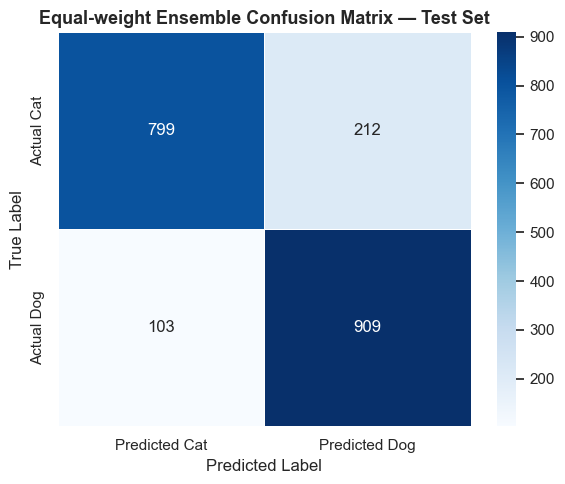

NameError: name 'true' is not defined

In [23]:
# Ensemble evaluation: average predicted probabilities from saved estimators
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import json, os

preds = []
for p in saved_model_paths:
    m = keras.models.load_model(p)
    test_gen.reset()
    pr = m.predict(test_gen, verbose=0).ravel()
    preds.append(pr)

avg_pred = np.mean(preds, axis=0)
y_pred = (avg_pred >= 0.5).astype(int)
y_true = test_gen.classes

print('Equal-weight Ensemble Accuracy:', accuracy_score(y_true, y_pred))
print('Classification Report (Equal-weight):')
print(classification_report(y_true, y_pred, target_names=['Cat (0)', 'Dog (1)']))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Cat', 'Predicted Dog'],
    yticklabels=['Actual Cat', 'Actual Dog'], ax=ax, linewidths=0.5
)
ax.set_title('Equal-weight Ensemble Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Weighted ensemble: try to load saved weights (from ensemble_weights_summary.json) or fall back to proportional weights
weights_file = os.path.join(output_dir, 'ensemble_weights_summary.json') if 'output_dir' in globals() else 'ensemble_weights_summary.json'
if os.path.exists(weights_file):
    w_summary = json.load(open(weights_file))
    weights = w_summary.get('best_val_weights', None)
    if weights is not None:
        weights = np.array(weights)
else:
    weights = None

if weights is None:
    # fallback: weight proportional to per-model accuracy
    per_acc = [accuracy_score(y_true, (p >= 0.5).astype(int)) for p in preds]
,
,
4
,
,
,
0.5
,
,
,
,
,
5
,
,
,
,
,
,
,
,
,
,
,
,
true
,
0.5
,
,
2
5
,
1
,
,
,
,
,
,
,
,
,
,
,
1
,

,
,
,
,
,
,
,
,
,
,
,
